### Find local arrangements

In [ ]:
# We load relevant module.
from sea_urchin.sea_urchin import SeaUrchin
# Import plotting function
from sea_urchin.plotting.rendering import plot_structures
# For structure visualization
import ase
import ase.visualize
%matplotlib inline 

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import ira_mod, fastoverlap

#### Whole Molecule Local Environments

In [3]:
# We define some input parameters, like the name and location of the input files,
# the atoms of interest and the size of the cutoff radii.

# LAMMPS trajectory file
lmp_file = "./results/lammps.298K.prod.lammpstrj"

# LAMMPS data file
bgf_file = "data.lammps" # no need to respecify the folder here (will change probably tho)

# Element specific cutoff radius, we choose 2.6 for O, 3.2 for H, 2.8 for Cl due to 
# their corresponding solvation radius in RDF.
# 3.0 for Li due to it is big enough to cover both O and Cl
cutoff_dist = {
    "O": 3.35,
    "N": 5.5,
    "F": 5.5  
    }

# Element at the center of the coordination environments
ref_atom = "Na"

# Elements that we want to include in the coordination environments.
# Everything else will be discarded (e.g. hydrogen atoms)
coord_env = ["N", "O", "S", "Na", "H", "F", "C"]

reconstruct = {
    "type"    : {1 : "molecules",
                 2 : "molecules",
                 3 : "molecules",
                 4 : "molecules",
                 5 : "molecules",
                 6 : "molecules",
                 7 : "molecules",
                 8 : "molecules",
                 9 : "molecules",
                 10 : "molecules",
                 12 : "molecules",
                 
                 # "2" is the LAMMPS atom type, still work in progress to make it clearer
                },     # Reconstruct the coordination environment. "molecules" to include full molecules,
                       # "neighbors" to only reconstruct nearest neighbors of the coordinating atoms
    "depth"   : 1,     # when you reconstruct by neighbors, number of nth neighbors to include
    "inverse" : False, # if True, take the negative (e.g. everything that is NOT coordinated)
    "merge"   : False   # merge coordination environments if they share atoms
    }

In [34]:
obj = SeaUrchin(lmp_file,
                bgf_file    = bgf_file,
                # pmf_file    = pmf_file,
                ref_atom    = ref_atom,
                coord_env   = coord_env,
                cutoff_dist = cutoff_dist,
                parallel    = True,
                # col_file = col_file,
                # multiple_replica  = multiple_replica,
                nframes     = 15000, # how many frames include, if commented read the whole trajectory
                skip_frames = 0, # skip the first N frames 
                nstrides    = 100,  # read every Nth frame
                save_name   = "urchin_Na.pkl",
                reconstruct = reconstruct,
                free_energy = False,
                save        = True,
                )

Starting to read input file file:
lammps.298K.prod.lammpstrj
File format found, treated as: lammps
Initializing from scratch. Hang in there.
Reading provided trajectory.
All trajectories read in in 643.775 s.
Converted in ASE format in 11.58 s.
Trajectory done. Dividing into clusters.
Clusters created in 132.62 s - finishing the object.
Saved everything as results//urchin_Na.pkl
SeaUrchin operation completed in 1420.067 s.


In [35]:
obj = SeaUrchin()

Counter({'C79H46F120N12NaO62S36': 7080, 'C58H44F80N8NaO44S24': 6094, 'C54H34F80N8NaO42S24': 5250, 'C83H56F120N12NaO64S36': 4243, 'C104H58F160N16NaO82S48': 2346, 'C75H36F120N12NaO60S36': 2259, 'C58H44F80N8NaO43S24': 1308, 'C62H54F80N8NaO46S24': 1195, 'C100H48F160N16NaO80S48': 997, 'C33H32F40N4NaO24S12': 964, 'C50H24F80N8NaO40S24': 957, 'C108H68F160N16NaO84S48': 909, 'C83H56F120N12NaO63S36': 813, 'C29H22F40N4NaO22S12': 762, 'C79H46F120N12NaO61S36': 711, 'C129H70F200N20NaO102S60': 609, 'C37H42F40N4NaO26S12': 463, 'C87H66F120N12NaO66S36': 370, 'C62H54F80N8NaO45S24': 272, 'C33H32F40N4NaO23S12': 184, 'C104H58F160N16NaO81S48': 170, 'C54H34F80N8NaO41S24': 136, 'C37H42F40N4NaO25S12': 108, 'C125H60F200N20NaO100S60': 58, 'C108H68F160N16NaO83S48': 55, 'C87H66F120N12NaO65S36': 52, 'C112H78F160N16NaO86S48': 52, 'C133H80F200N20NaO104S60': 41, 'C54H34F80N9NaO41S24': 34, 'C58H44F80N8NaO42S24': 28, 'C83H56F120N12NaO62S36': 27, 'C12H30NaO6': 27, 'C58H44F80N9NaO44S24': 19, 'C54H34F80N9NaO42S24': 9, 'C83H5

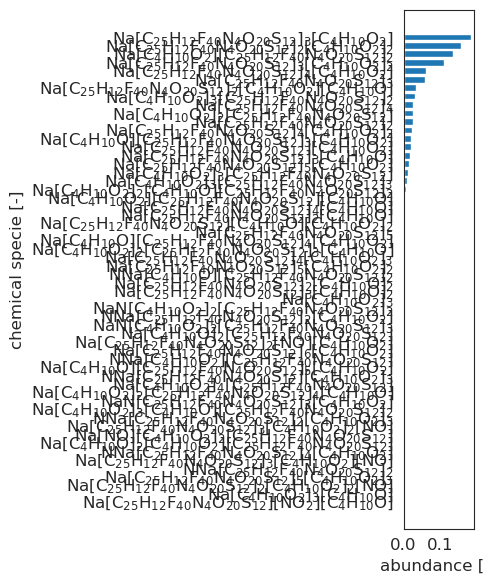

In [36]:
# Plot the distribution of coordination environments by chemical formula
obj.plot_abundance() 

In [37]:
obj.cluster_types

Counter({'C79H46F120N12NaO62S36': 7080,
         'C58H44F80N8NaO44S24': 6094,
         'C54H34F80N8NaO42S24': 5250,
         'C83H56F120N12NaO64S36': 4243,
         'C104H58F160N16NaO82S48': 2346,
         'C75H36F120N12NaO60S36': 2259,
         'C58H44F80N8NaO43S24': 1308,
         'C62H54F80N8NaO46S24': 1195,
         'C100H48F160N16NaO80S48': 997,
         'C33H32F40N4NaO24S12': 964,
         'C50H24F80N8NaO40S24': 957,
         'C108H68F160N16NaO84S48': 909,
         'C83H56F120N12NaO63S36': 813,
         'C29H22F40N4NaO22S12': 762,
         'C79H46F120N12NaO61S36': 711,
         'C129H70F200N20NaO102S60': 609,
         'C37H42F40N4NaO26S12': 463,
         'C87H66F120N12NaO66S36': 370,
         'C62H54F80N8NaO45S24': 272,
         'C33H32F40N4NaO23S12': 184,
         'C104H58F160N16NaO81S48': 170,
         'C54H34F80N8NaO41S24': 136,
         'C37H42F40N4NaO25S12': 108,
         'C125H60F200N20NaO100S60': 58,
         'C108H68F160N16NaO83S48': 55,
         'C87H66F120N12NaO65S36': 

In [38]:
obj.cluster_types.keys()

dict_keys(['C83H56F120N12NaO64S36', 'C58H44F80N8NaO43S24', 'C58H44F80N8NaO44S24', 'C79H46F120N12NaO62S36', 'C75H36F120N12NaO60S36', 'C54H34F80N8NaO42S24', 'C50H24F80N8NaO40S24', 'C83H56F120N12NaO63S36', 'C104H58F160N16NaO82S48', 'C87H66F120N12NaO66S36', 'C100H48F160N16NaO80S48', 'C104H58F160N16NaO81S48', 'C33H32F40N4NaO24S12', 'C29H22F40N4NaO22S12', 'C37H42F40N4NaO25S12', 'C79H46F120N12NaO61S36', 'C129H70F200N20NaO102S60', 'C62H54F80N8NaO46S24', 'C83H56F120N12NaO62S36', 'C87H66F120N12NaO65S36', 'C37H42F40N4NaO26S12', 'C108H68F160N16NaO84S48', 'C112H78F160N16NaO85S48', 'C62H54F80N8NaO45S24', 'C33H32F40N4NaO23S12', 'C125H60F200N20NaO100S60', 'C33H32F40N4NaO22S12', 'C12H30NaO6', 'C58H44F80N9NaO44S24', 'C108H68F160N16NaO83S48', 'C112H78F160N16NaO86S48', 'C133H80F200N20NaO104S60', 'C54H34F80N9NaO43S24', 'C37H42F40N4NaO24S12', 'C58H44F80N8NaO42S24', 'C104H58F160N17NaO82S48', 'C79H46F120N13NaO62S36', 'C66H64F80N8NaO47S24', 'C133H80F200N20NaO103S60', 'C54H34F80N8NaO41S24', 'C54H34F80N9NaO41S24

In [39]:
import sea_urchin.utilities.auxiliary_functions as aux

In [40]:
from collections import Counter

# Get the 10 most common cluster types
top_10_clusters = Counter(obj.cluster_types).most_common(10)

for i, (cluster_formula, count) in enumerate(top_10_clusters):
    print(f"{i+1}. {cluster_formula} ({count} occurrences)")
    structure = obj.get_cluster_with_formula(f"{cluster_formula}")[0]
    chemical_formula = aux.generate_chemical_string(structure)
    structure.write(f"./clusters/{chemical_formula}_top{i+1}.pdb")

1. C79H46F120N12NaO62S36 (7080 occurrences)
2. C58H44F80N8NaO44S24 (6094 occurrences)
3. C54H34F80N8NaO42S24 (5250 occurrences)
4. C83H56F120N12NaO64S36 (4243 occurrences)
5. C104H58F160N16NaO82S48 (2346 occurrences)
6. C75H36F120N12NaO60S36 (2259 occurrences)
7. C58H44F80N8NaO43S24 (1308 occurrences)
8. C62H54F80N8NaO46S24 (1195 occurrences)
9. C100H48F160N16NaO80S48 (997 occurrences)
10. C33H32F40N4NaO24S12 (964 occurrences)


In [41]:
import matplotlib.pyplot as plt
from collections import Counter

# Get top 10 most common clusters
top_10 = Counter(obj.cluster_types).most_common(10)

# Split into labels and counts
formulas, counts = zip(*top_10)

# Plot
# plt.figure(figsize=(12, 6))
# plt.bar(range(len(formulas)), counts, tick_label=formulas)
# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Count")

In [42]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Constants
kBT=1

# Get counts for all species
cluster_counter = Counter(obj.cluster_types)
total_count = sum(cluster_counter.values())

# Compute probability and free energy for all
free_energy_dict = {
    formula: -kBT * np.log(count / total_count)
    for formula, count in cluster_counter.items()
}

# Normalize free energy (lowest G = 0)
min_G = min(free_energy_dict.values())
free_energy_dict = {
    formula: G - min_G for formula, G in free_energy_dict.items()
}

# Select top 10 most common clusters
top_10 = cluster_counter.most_common(10)
formulas = [f for f, _ in top_10]
free_energies = [free_energy_dict[f] for f in formulas]

# # Plot
# plt.figure(figsize=(12, 6))
# plt.bar(range(len(formulas)), free_energies, tick_label=formulas)
# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Free Energy (kJ/mol)")
# plt.title("Free Energy Surface of Top 10 Clusters (-kBT ln p)")
# plt.tight_layout()
# plt.show()

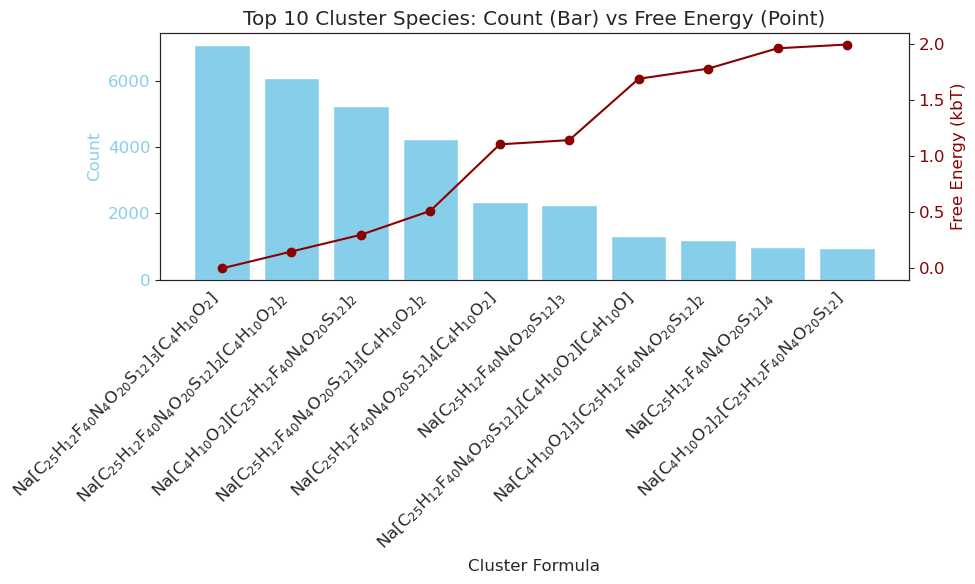

In [49]:
plt.rcParams.update({'font.size': 12})
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for counts
bar = ax1.bar(range(len(formulas)), counts, color='skyblue', label='Count')
ax1.set_xlabel('Cluster Formula')
ax1.set_ylabel('Count', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(range(len(formulas)))
formula_names = [aux.generate_chemical_string(obj.get_cluster_with_formula(f)[0]) for f in formulas]
ax1.set_xticklabels(formula_names, rotation=45, ha='right')
ax1.set_title("Top 10 Cluster Species: Count (Bar) vs Free Energy (Point)")

# Line/point plot for free energy on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(range(len(formulas)), free_energies, color='darkred', marker='o', label='Free Energy')
ax2.set_ylabel('Free Energy (kbT)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

fig.tight_layout()
plt.show()

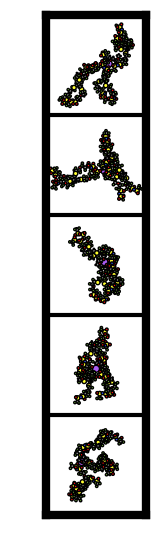

In [44]:
plot_structures(obj.get_cluster_with_formula("C79H46F120N12NaO62S36")[:5], n=5)

In [45]:
structure = obj.get_cluster_with_formula("C79H46F120N12NaO62S36")[0]